In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Read the dataset
file_path = 'ALL_PREDICTED.csv'
df = pd.read_csv(file_path)

# 2. Preprocessing
# Parse date
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Separate "Actual" column from "Model" columns
actual_col = 'actual'
model_cols = [c for c in df.columns if c != actual_col]

# 3. Identify the "First Valid Index" for each model
# This maps each model name to the integer index (row number) where its predictions start
model_start_indices = {}
for m in model_cols:
    # find the first index where the value is not NaN
    first_valid = df[m].first_valid_index()
    # convert timestamp index to integer location if necessary, or just use integer indexing on the dataframe
    # To be safe and consistent, we'll get the integer location (0, 1, 2...)
    model_start_indices[m] = df.index.get_loc(first_valid)

print(f"Data Loaded. Total observations: {len(df)}")
print(f"Number of models: {len(model_cols)}")
print("Sample start indices (lookback periods):")
for m in model_cols:
    print(f"  {m}: starts at row {model_start_indices[m]}")

Data Loaded. Total observations: 730
Number of models: 60
Sample start indices (lookback periods):
  gru_baseline_42: starts at row 20
  lstm_baseline_42: starts at row 20
  tcn_baseline_42: starts at row 20
  transformer_baseline_42: starts at row 20
  gru_baseline_73: starts at row 20
  lstm_baseline_73: starts at row 20
  tcn_baseline_73: starts at row 20
  transformer_baseline_73: starts at row 20
  gru_baseline_1234: starts at row 20
  lstm_baseline_1234: starts at row 20
  tcn_baseline_1234: starts at row 20
  transformer_baseline_1234: starts at row 20
  gru_baseline_31415: starts at row 20
  lstm_baseline_31415: starts at row 20
  tcn_baseline_31415: starts at row 20
  transformer_baseline_31415: starts at row 20
  gru_baseline_271828183: starts at row 20
  lstm_baseline_271828183: starts at row 20
  tcn_baseline_271828183: starts at row 20
  transformer_baseline_271828183: starts at row 20
  gru_rs_42: starts at row 90
  lstm_rs_42: starts at row 30
  tcn_rs_42: starts at row 

In [8]:
def diebold_mariano_test(y_true, y_pred1, y_pred2, h=1, metric='MSE'):
    """
    Computes the Diebold-Mariano test statistic and p-value.
    
    Args:
        y_true: Actual values
        y_pred1: Predictions from Model 1
        y_pred2: Predictions from Model 2
        h: Forecast horizon (steps ahead), default 1
        metric: Loss function, 'MSE' or 'MAE'
        
    Returns:
        dm_stat: Negative -> Model 1 is better (lower loss). Positive -> Model 2 is better.
        p_value: Two-sided p-value
    """
    # Calculate errors
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2
    
    # Calculate loss differential
    if metric == 'MSE':
        d = e1**2 - e2**2
    elif metric == 'MAE':
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("Metric must be 'MSE' or 'MAE'")
        
    T = len(d)
    mean_d = np.mean(d)
    
    # Calculate variance of d (using HAC estimator if h > 1)
    gamma0 = np.var(d, ddof=1)
    if h > 1:
        gamma = []
        for lag in range(1, h):
            cov = np.cov(d[:-lag], d[lag:])[0, 1]
            gamma.append(cov)
        var_d = gamma0 + 2 * sum(gamma)
    else:
        var_d = gamma0
        
    # Handle case where models are identical
    if var_d == 0:
        return 0.0, 1.0
        
    # DM statistic
    dm_stat = mean_d / np.sqrt(var_d / T)
    
    # p-value (2-sided test)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    
    return dm_stat, p_value

In [9]:
n_models = len(model_cols)
dm_matrix = np.zeros((n_models, n_models))
p_matrix = np.zeros((n_models, n_models))

print("Computing pairwise DM tests...")

for i, m1 in enumerate(model_cols):
    for j, m2 in enumerate(model_cols):
        if i == j:
            # Comparison with self
            dm_matrix[i, j] = 0
            p_matrix[i, j] = 1.0
            continue
            
        # DYNAMIC SLICING LOGIC:
        # 1. Get start indices for both models
        start_1 = model_start_indices[m1]
        start_2 = model_start_indices[m2]
        
        # 2. Start the test at the LATER of the two start points (biggest lookback)
        #    This ensures we only compare where BOTH models have valid data.
        comparison_start = max(start_1, start_2)
        
        # 3. Slice the data
        #    We use .iloc for integer-position slicing
        y_true_slice = df[actual_col].iloc[comparison_start:].values
        y_pred1_slice = df[m1].iloc[comparison_start:].values
        y_pred2_slice = df[m2].iloc[comparison_start:].values
        
        # Check if we have enough data points to run the test
        if len(y_true_slice) < 5: # Arbitrary small threshold
            # Not enough data to compare
            dm_matrix[i, j] = np.nan
            p_matrix[i, j] = np.nan
        else:
            stat, p = diebold_mariano_test(y_true_slice, y_pred1_slice, y_pred2_slice)
            dm_matrix[i, j] = stat
            p_matrix[i, j] = p

# Convert to DataFrames for easier handling and visualization
dm_df = pd.DataFrame(dm_matrix, index=model_cols, columns=model_cols)
p_df = pd.DataFrame(p_matrix, index=model_cols, columns=model_cols)

print("Computation complete.")

Computing pairwise DM tests...
Computation complete.


In [10]:
alpha = 0.05  # Significance level (95% confidence)
confidence_set = []
eliminated_models = []

for m1 in model_cols:
    is_eliminated = False
    for m2 in model_cols:
        if m1 == m2: continue
        
        # Logic:
        # If DM_Stat(m1, m2) > 0, it means Error(m1) > Error(m2), so m1 is WORSE.
        # If p_value < alpha, this difference is statistically significant.
        # Therefore, m2 "beats" m1.
        
        stat = dm_df.loc[m1, m2]
        p_val = p_df.loc[m1, m2]
        
        if stat > 0 and p_val < alpha:
            is_eliminated = True
            eliminated_models.append(m1)
            break # m1 is out, stop checking against other models
            
    if not is_eliminated:
        confidence_set.append(m1)

print(f"Total Models: {len(model_cols)}")
print(f"Models in Confidence Set: {len(confidence_set)}")
print("-" * 30)
for m in confidence_set:
    print(f" -> {m}")

Total Models: 60
Models in Confidence Set: 1
------------------------------
 -> tcn_optuna_73


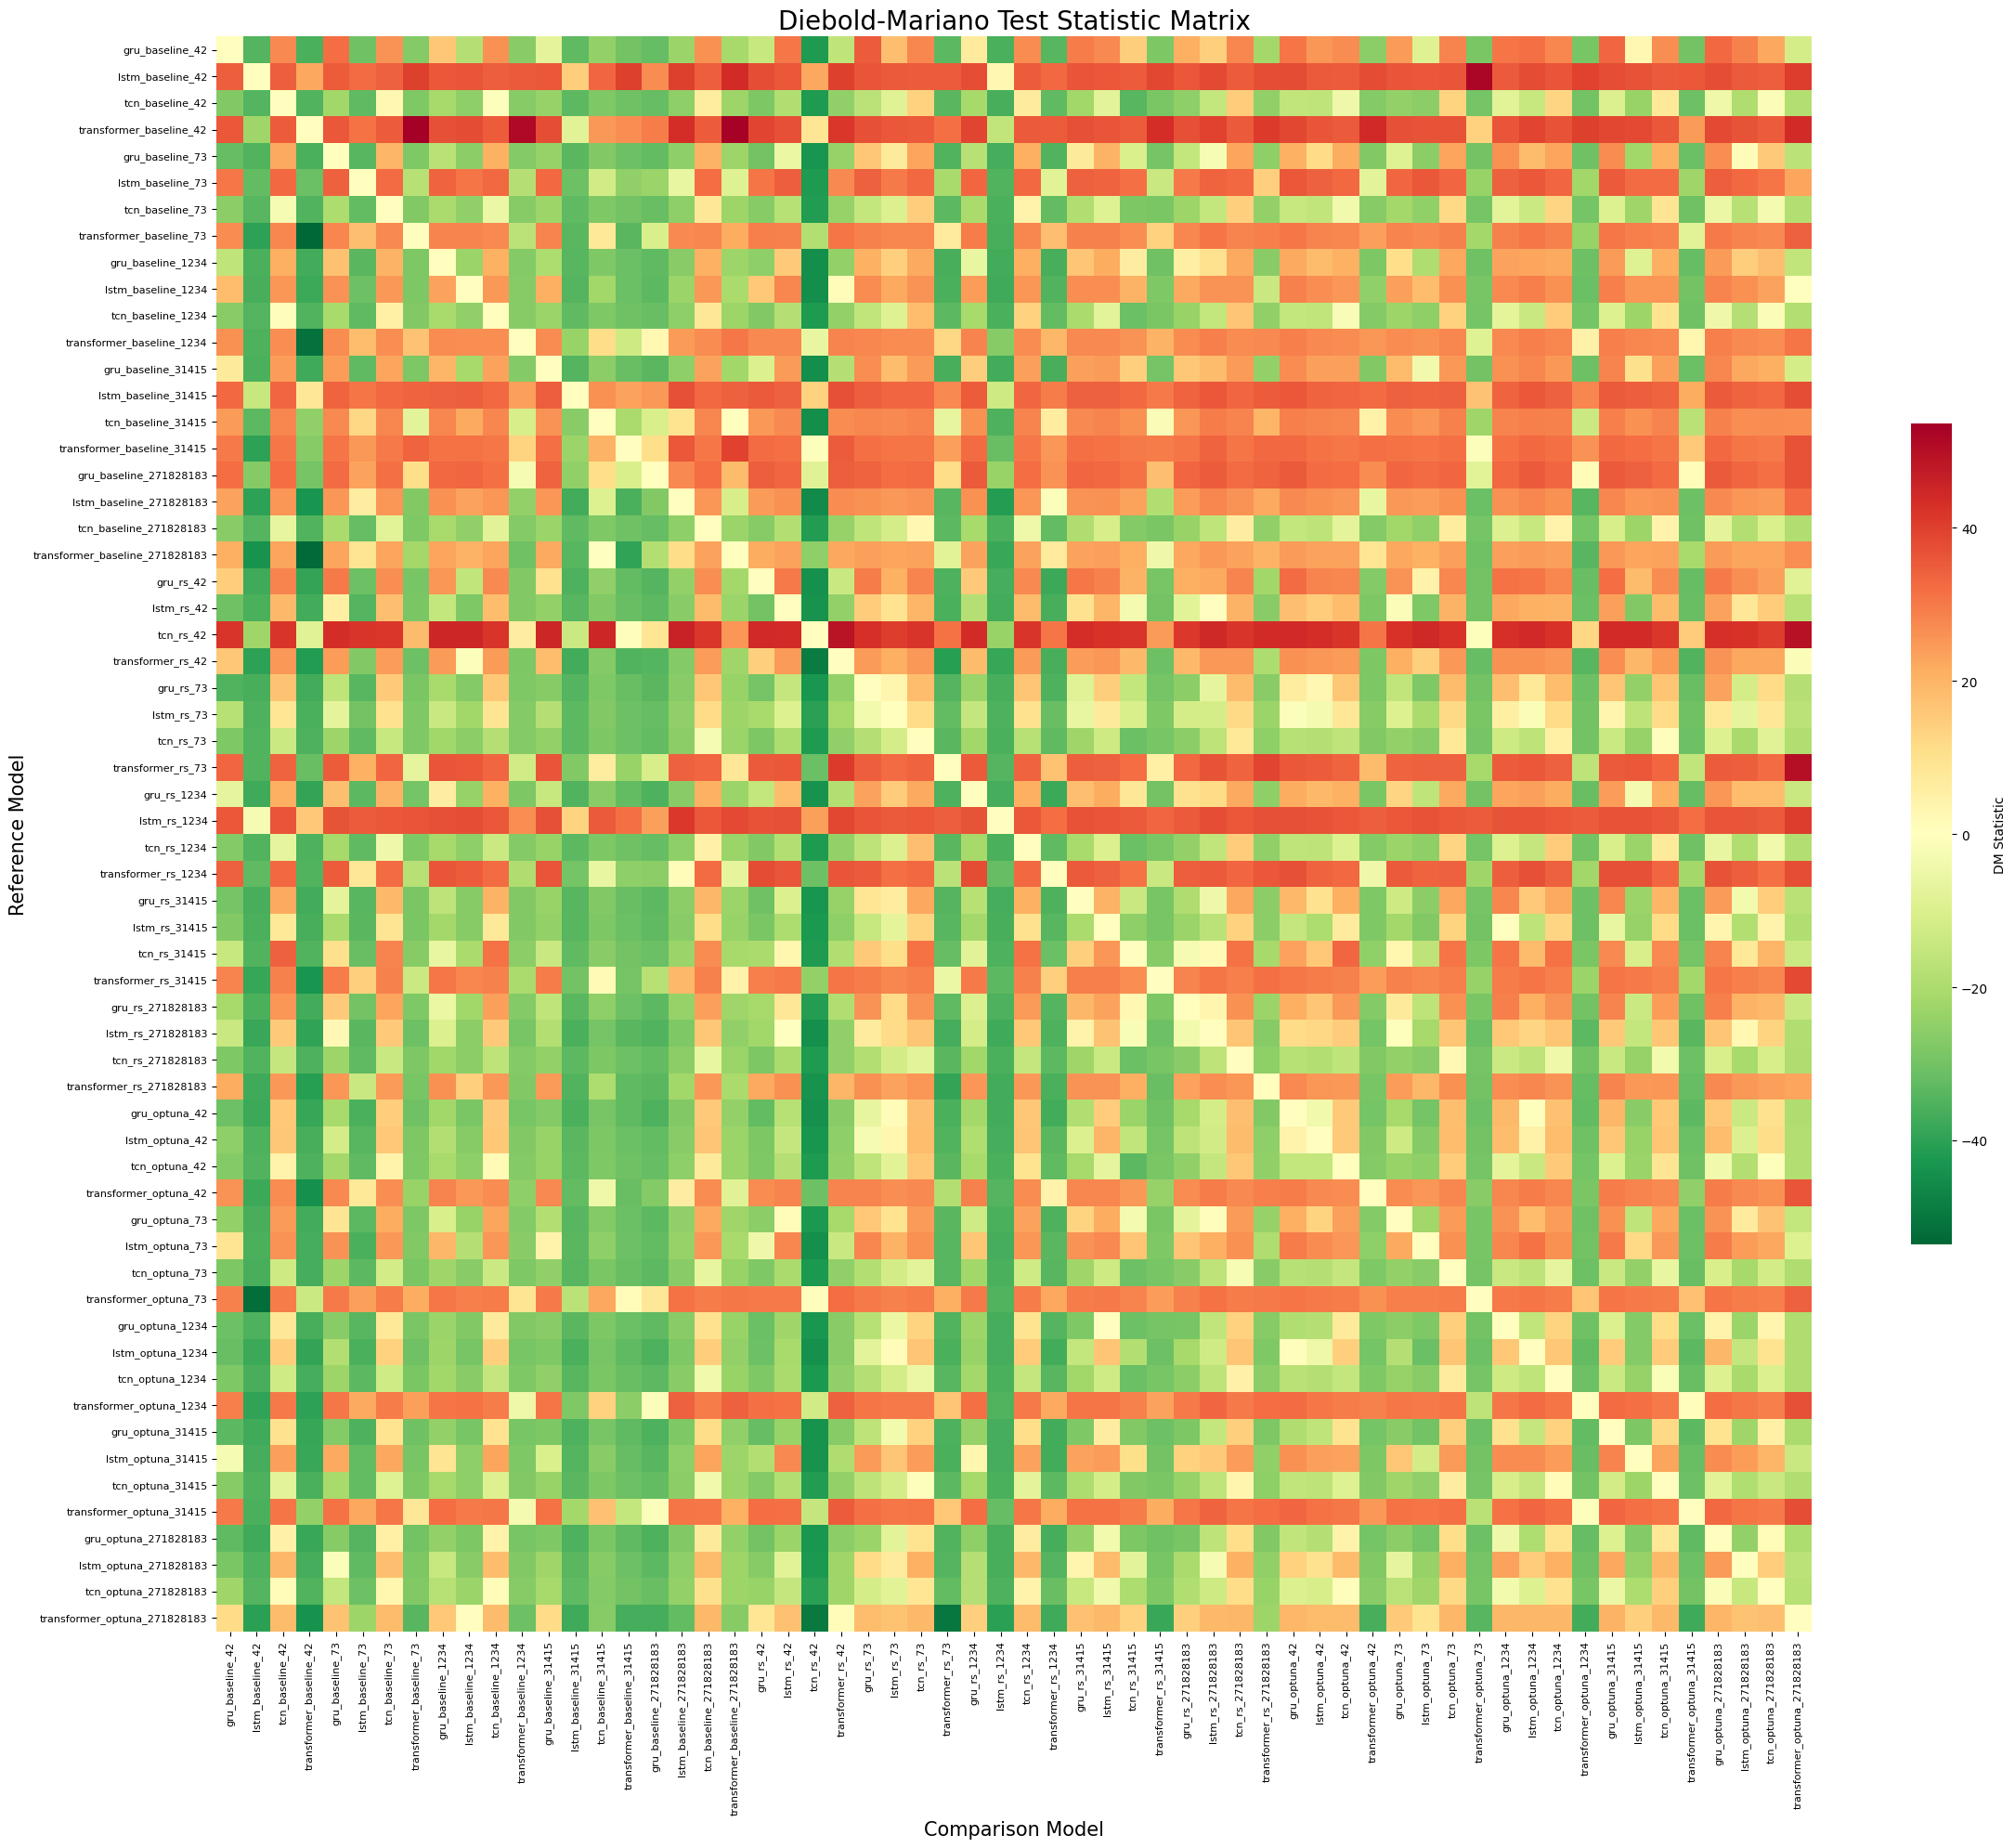

In [11]:
plt.figure(figsize=(24, 20))

# Create a mask for NaNs if any exist
mask = dm_df.isna()

# Plot Heatmap of the DM Statistics
sns.heatmap(dm_df, 
            mask=mask,
            cmap='RdYlGn_r',  # Red = Positive (Row is Worse), Green = Negative (Row is Better)
            center=0,
            square=True,
            cbar_kws={"shrink": .5, "label": "DM Statistic"},
            xticklabels=model_cols,
            yticklabels=model_cols)

plt.title('Diebold-Mariano Test Statistic Matrix', fontsize=20)
plt.xlabel('Comparison Model', fontsize=15)
plt.ylabel('Reference Model', fontsize=15)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract Unique Options for Filters
# Parse column names to get lists of all Schemes, Models, and Seeds
all_schemes = sorted(list(set([c.split('_')[1] for c in model_cols])))
all_models  = sorted(list(set([c.split('_')[0] for c in model_cols])))
all_seeds   = sorted(list(set([c.split('_')[2] for c in model_cols])))

# 2. Create Widgets
style = {'description_width': 'initial'}

# Dropdown for Filter Type
filter_type_dd = widgets.Dropdown(
    options=['Scheme', 'Model', 'Seed', 'Show All'],
    value='Scheme',
    description='Filter Criteria:',
    style=style
)

# Dropdown for Specific Value (Dynamic)
filter_value_dd = widgets.Dropdown(
    options=all_schemes,
    description='Select Group:',
    style=style
)

# Slider for Significance Level
alpha_slider = widgets.FloatSlider(
    value=0.05,
    min=0.01,
    max=0.20,
    step=0.01,
    description='Significance (Alpha):',
    style=style
)

# 3. Define Interaction Logic
def on_filter_type_change(change):
    """Updates the 'Select Group' dropdown options based on the Criteria selection."""
    selection = change['new']
    if selection == 'Scheme':
        filter_value_dd.options = all_schemes
        filter_value_dd.disabled = False
    elif selection == 'Model':
        filter_value_dd.options = all_models
        filter_value_dd.disabled = False
    elif selection == 'Seed':
        filter_value_dd.options = all_seeds
        filter_value_dd.disabled = False
    else: # Show All
        filter_value_dd.options = ['All Models']
        filter_value_dd.disabled = True

filter_type_dd.observe(on_filter_type_change, names='value')

# 4. Main Plotting Function
def update_dashboard(filter_type, filter_value, alpha):
    # Determine which columns to include
    if filter_type == 'Show All':
        subset_cols = model_cols
        title_suffix = "All Models"
    else:
        # Filter logic
        subset_cols = []
        for col in model_cols:
            parts = col.split('_')
            m, s, seed = parts[0], parts[1], parts[2]
            
            if filter_type == 'Scheme' and s == filter_value:
                subset_cols.append(col)
            elif filter_type == 'Model' and m == filter_value:
                subset_cols.append(col)
            elif filter_type == 'Seed' and seed == filter_value:
                subset_cols.append(col)
        title_suffix = f"{filter_type}: {filter_value}"

    if not subset_cols:
        print("No models found matching criteria.")
        return

    # Subset the DataFrames
    sub_dm = dm_df.loc[subset_cols, subset_cols]
    sub_p = p_df.loc[subset_cols, subset_cols]

    # Calculate Confidence Set for this specific subset
    confidence_set = []
    eliminated = set()
    
    for m1 in subset_cols:
        is_eliminated = False
        for m2 in subset_cols:
            if m1 == m2: continue
            # If m1 is significantly worse than m2
            if sub_dm.loc[m1, m2] > 0 and sub_p.loc[m1, m2] < alpha:
                is_eliminated = True
                eliminated.add(m1)
                break
        if not is_eliminated:
            confidence_set.append(m1)

    # --- VISUALIZATION ---
    # Create a wider layout: Text on left, Heatmap on right? 
    # For notebooks, stacking is usually safer.
    
    print(f"📊 ANALYSIS REPORT: {title_suffix}")
    print(f"Confidence Level: {100*(1-alpha):.0f}% (Alpha={alpha})")
    print(f"Total Models in View: {len(subset_cols)}")
    print("-" * 50)
    print(f"🏆 MODEL CONFIDENCE SET (The 'Winners'): {len(confidence_set)} model(s)")
    for m in confidence_set:
        print(f"  ✅ {m}")
    print("-" * 50)
    
    # Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(sub_dm, 
                cmap='RdYlGn_r', 
                center=0, 
                annot=len(subset_cols) < 15, # Only show numbers if matrix is small
                fmt='.1f',
                square=True,
                cbar_kws={'label': 'DM Statistic (Green = Row Better)'})
    plt.title(f"Diebold-Mariano Matrix ({title_suffix})", fontsize=14)
    plt.show()

# 5. Display the GUI
# Using interactive_output to link widgets to the function
ui = widgets.HBox([filter_type_dd, filter_value_dd, alpha_slider])
out = widgets.interactive_output(update_dashboard, {
    'filter_type': filter_type_dd, 
    'filter_value': filter_value_dd, 
    'alpha': alpha_slider
})

display(ui, out)

Output()